# 02 — Preprocessing
**Dataset:** Credit Card Fraud Detection  
**Cilj:** Pripremiti podatke za treniranje neuronskih mreža — čišćenje, skaliranje, stratifikovani split, i tretman nebalansiranosti klasa.

---

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Kreiranje direktorijuma ako ne postoje
os.makedirs('../results', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

print('✅ Imports OK')

✅ Imports OK


## 1. Učitavanje sirovih podataka

In [2]:
DATA_PATH = '../data/creditcard.csv'

df = pd.read_csv(DATA_PATH)
print(f'Originalna shape: {df.shape}')
print(f'Klase: {dict(df["Class"].value_counts())}')
df.head(3)

Originalna shape: (284807, 31)
Klase: {0: np.int64(284315), 1: np.int64(492)}


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


## 2. Čišćenje podataka

In [3]:
# 2.1 Provjera nedostajućih vrednosti
missing = df.isnull().sum().sum()
print(f'Nedostajuće vrednosti: {missing}')

# 2.2 Uklanjanje duplikata (čuvamo prvi red)
n_before = len(df)
df = df.drop_duplicates()
n_after = len(df)
print(f'Uklonjeni duplikati: {n_before - n_after} redova')
print(f'Shape posle čišćenja: {df.shape}')
print(f'Klase posle čišćenja: {dict(df["Class"].value_counts())}')

Nedostajuće vrednosti: 0
Uklonjeni duplikati: 1081 redova
Shape posle čišćenja: (283726, 31)
Klase posle čišćenja: {0: np.int64(283253), 1: np.int64(473)}


## 3. Feature Engineering — Time i Amount transformacija

Featurei posle transformacije: 31 (+ Class)
Nove kolone: Time_sin, Time_cos, Amount_log


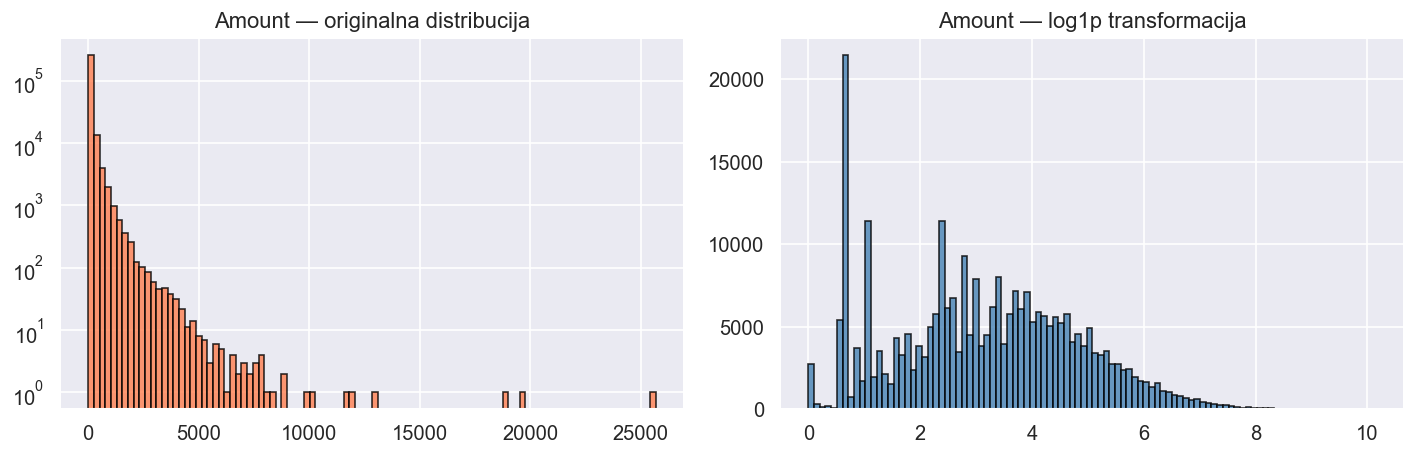

In [4]:
df_proc = df.copy()

# 3.1 Time -> ciklične featurei (sin/cos transformacija, jer je Time periodičan — 24h ciklus)
seconds_in_day = 86400
df_proc['Time_sin'] = np.sin(2 * np.pi * df_proc['Time'] / seconds_in_day)
df_proc['Time_cos'] = np.cos(2 * np.pi * df_proc['Time'] / seconds_in_day)

# 3.2 Amount -> log transformacija (desno asimetrična distribucija)
df_proc['Amount_log'] = np.log1p(df_proc['Amount'])   # log1p = log(1+x) -> bezbedan za Amount=0

# 3.3 Uklanjamo originalne Time i Amount (zamenjeni su transformisanim verzijama)
df_proc = df_proc.drop(columns=['Time', 'Amount'])

print(f'Featurei posle transformacije: {df_proc.shape[1] - 1} (+ Class)')
print(f'Nove kolone: Time_sin, Time_cos, Amount_log')

# Vizualizacija transformacije Amount
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Amount'], bins=100, color='coral', alpha=0.8, edgecolor='black')
axes[0].set_title('Amount — originalna distribucija')
axes[0].set_yscale('log')
axes[1].hist(df_proc['Amount_log'], bins=100, color='steelblue', alpha=0.8, edgecolor='black')
axes[1].set_title('Amount — log1p transformacija')
plt.tight_layout()
plt.savefig('../results/02_amount_transform.png', bbox_inches='tight')
plt.show()

## 4. Train / Validation / Test Split

In [5]:
# Odvajanje featuera i labele
X = df_proc.drop(columns=['Class'])
y = df_proc['Class']

print(f'X shape: {X.shape}')
print(f'y distribucija: {dict(y.value_counts())}')

# 70% train | 15% val | 15% test  (stratifikovano)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp
)

print(f'\nTrain: {X_train.shape} | Fraud: {y_train.sum()} ({y_train.mean()*100:.2f}%)')
print(f'Val:   {X_val.shape}   | Fraud: {y_val.sum()} ({y_val.mean()*100:.2f}%)')
print(f'Test:  {X_test.shape}  | Fraud: {y_test.sum()} ({y_test.mean()*100:.2f}%)')

X shape: (283726, 31)
y distribucija: {0: np.int64(283253), 1: np.int64(473)}

Train: (198608, 31) | Fraud: 331 (0.17%)
Val:   (42559, 31)   | Fraud: 71 (0.17%)
Test:  (42559, 31)  | Fraud: 71 (0.17%)


## 5. Skaliranje featuera

✅ Skaliranje završeno (RobustScaler, fit samo na train)
X_train_scaled — mean: 0.0166, std: 1.2475


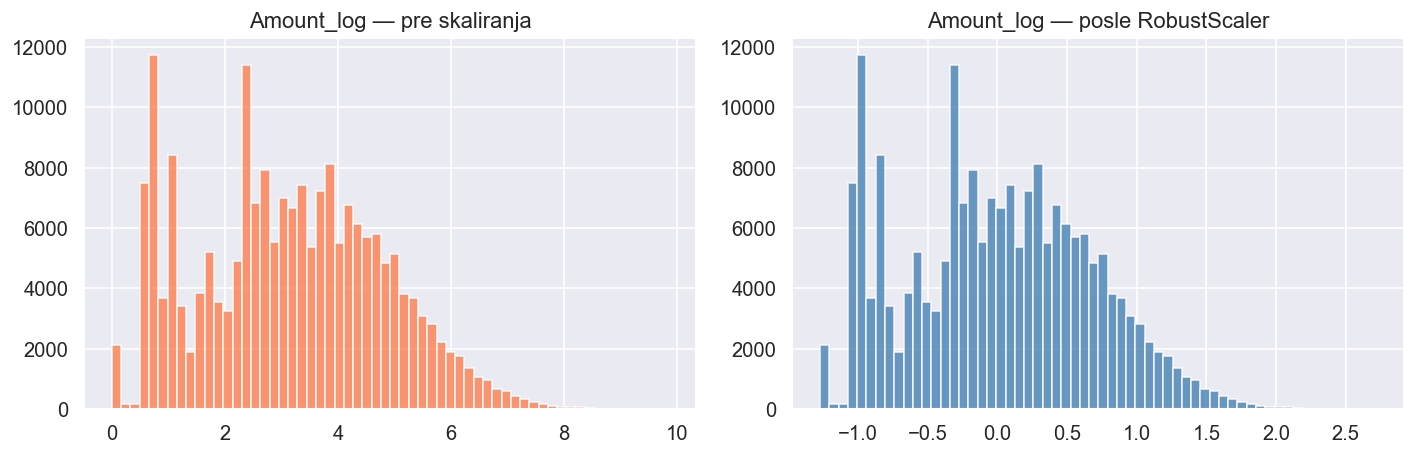

✅ Scaler sačuvan u ../models/robust_scaler.pkl


In [6]:
# RobustScaler je bolji izbor za ovaj dataset:
# - manje osetljiv na outliere (koristi medijanu i IQR umesto mean/std)
# - Amount ima outliere sa visokim vrednostima
# NAPOMENA: scaler fitujemo SAMO na train setu!

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print('✅ Skaliranje završeno (RobustScaler, fit samo na train)')
print(f'X_train_scaled — mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}')

# Vizualizacija pre/posle skaliranja za Amount_log
amount_idx = list(X.columns).index('Amount_log')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_train['Amount_log'], bins=60, color='coral', alpha=0.8)
axes[0].set_title('Amount_log — pre skaliranja')
axes[1].hist(X_train_scaled[:, amount_idx], bins=60, color='steelblue', alpha=0.8)
axes[1].set_title('Amount_log — posle RobustScaler')
plt.tight_layout()
plt.savefig('../results/02_scaling_comparison.png', bbox_inches='tight')
plt.show()

# Čuvanje scalera za kasniju upotrebu u evaluaciji
joblib.dump(scaler, '../models/robust_scaler.pkl')
print('✅ Scaler sačuvan u ../models/robust_scaler.pkl')

## 6. Tretman nebalansiranosti klasa

Zbog ekstremne nebalansiranosti (~0.17% fraud) koristimo tri pristupa i poredimo:

| Metoda | Opis | Pros | Cons |
|--------|------|------|------|
| **Bez tretmana + class_weight** | Originalni podaci, težinski loss | Jednostavno, nema gubitka info | Može loše za recall |
| **SMOTE** | Sintetički uzorci fraud klase | Više info za trening | Rizik overfittinga |
| **Kombinovani SMOTE + Undersampling** | Balans obe klase | Dobra ravnoteža | Gubi se info legit klase |

In [7]:
print('=== Originalni train set ===')
print(f'Distribucija: {Counter(y_train)}')

# --- Metoda 1: SMOTE (samo oversample fraud na 10% ---
smote = SMOTE(sampling_strategy=0.1, random_state=RANDOM_SEED, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f'\n=== Posle SMOTE (sampling_strategy=0.1) ===')
print(f'Distribucija: {Counter(y_train_smote)}')
print(f'Shape: {X_train_smote.shape}')

# --- Metoda 2: SMOTE + RandomUnderSampler (kombinovano) ---
over  = SMOTE(sampling_strategy=0.1, random_state=RANDOM_SEED, k_neighbors=5)
under = RandomUnderSampler(sampling_strategy=0.5, random_state=RANDOM_SEED)
pipeline = ImbPipeline([('over', over), ('under', under)])
X_train_combined, y_train_combined = pipeline.fit_resample(X_train_scaled, y_train)
print(f'\n=== Posle SMOTE + UnderSampling ===')
print(f'Distribucija: {Counter(y_train_combined)}')
print(f'Shape: {X_train_combined.shape}')

=== Originalni train set ===
Distribucija: Counter({0: 198277, 1: 331})

=== Posle SMOTE (sampling_strategy=0.1) ===
Distribucija: Counter({0: 198277, 1: 19827})
Shape: (218104, 31)

=== Posle SMOTE + UnderSampling ===
Distribucija: Counter({0: 39654, 1: 19827})
Shape: (59481, 31)


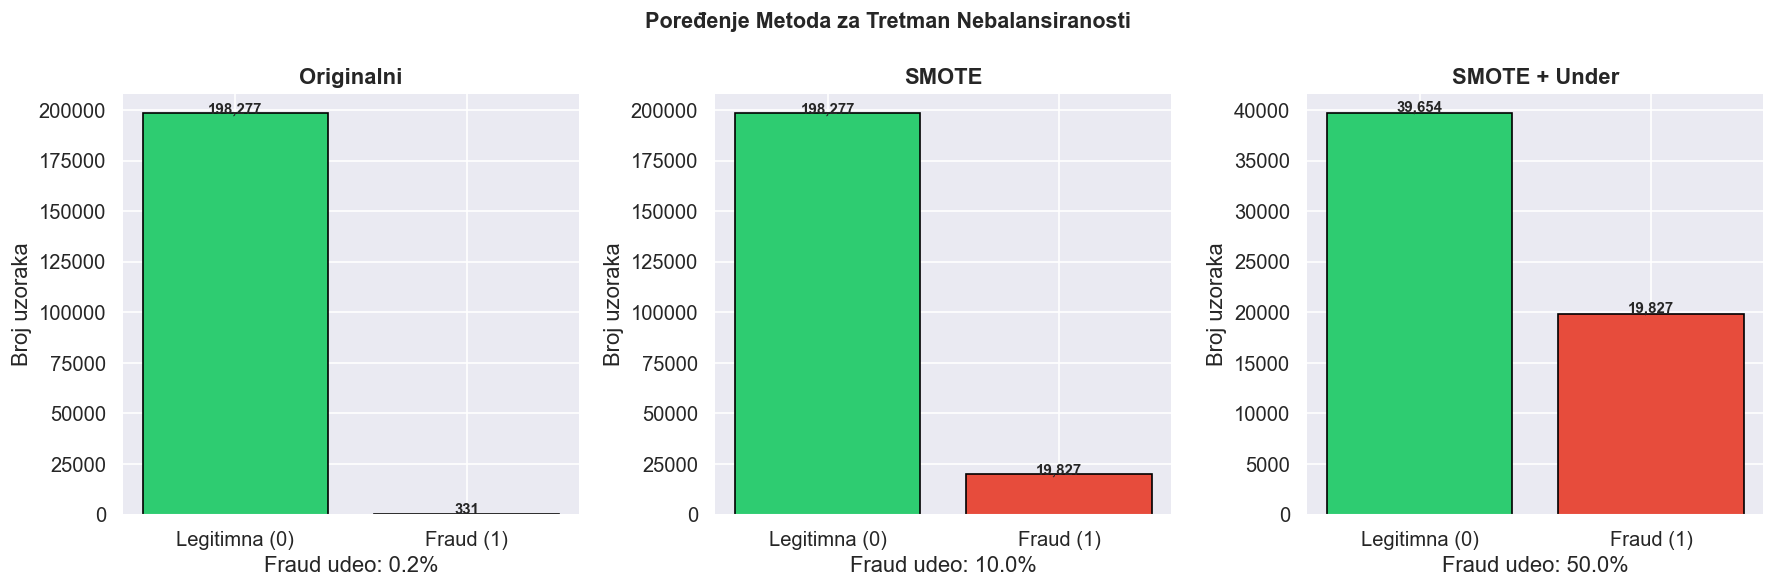

In [8]:
# Vizualizacija poređenja metoda
methods = {
    'Originalni': Counter(y_train),
    'SMOTE': Counter(y_train_smote),
    'SMOTE + Under': Counter(y_train_combined)
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = [['#2ecc71', '#e74c3c']] * 3

for ax, (name, counts) in zip(axes, methods.items()):
    labels = ['Legitimna (0)', 'Fraud (1)']
    vals = [counts[0], counts[1]]
    bars = ax.bar(labels, vals, color=['#2ecc71', '#e74c3c'], edgecolor='black')
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Broj uzoraka')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{val:,}', ha='center', fontsize=9, fontweight='bold')
    ratio = vals[1] / vals[0] * 100
    ax.set_xlabel(f'Fraud udeo: {ratio:.1f}%')

plt.suptitle('Poređenje Metoda za Tretman Nebalansiranosti', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/02_balancing_comparison.png', bbox_inches='tight')
plt.show()

## 7. Računanje class_weight za loss funkciju

In [9]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print('Class weights (za Keras/PyTorch loss):')  
print(f'  Klasa 0 (legitimna): {class_weight_dict[0]:.4f}')
print(f'  Klasa 1 (fraud):     {class_weight_dict[1]:.4f}')
print(f'  Odnos:               1 : {class_weight_dict[1]/class_weight_dict[0]:.1f}')

Class weights (za Keras/PyTorch loss):
  Klasa 0 (legitimna): 0.5008
  Klasa 1 (fraud):     300.0121
  Odnos:               1 : 599.0


## 8. Čuvanje procesiranih podataka

In [10]:
# Čuvamo sve varijante kao numpy arrays
PROC_PATH = '../data/processed/'

# Originalni (skalirani, bez resamplinga) — za class_weight pristup
np.save(f'{PROC_PATH}X_train.npy', X_train_scaled)
np.save(f'{PROC_PATH}X_val.npy', X_val_scaled)
np.save(f'{PROC_PATH}X_test.npy', X_test_scaled)
np.save(f'{PROC_PATH}y_train.npy', y_train.values)
np.save(f'{PROC_PATH}y_val.npy', y_val.values)
np.save(f'{PROC_PATH}y_test.npy', y_test.values)

# SMOTE varijanta
np.save(f'{PROC_PATH}X_train_smote.npy', X_train_smote)
np.save(f'{PROC_PATH}y_train_smote.npy', y_train_smote)

# Kombinovana varijanta
np.save(f'{PROC_PATH}X_train_combined.npy', X_train_combined)
np.save(f'{PROC_PATH}y_train_combined.npy', y_train_combined)

# Class weights kao dictionary
import json
with open(f'{PROC_PATH}class_weights.json', 'w') as f:
    json.dump({str(k): v for k, v in class_weight_dict.items()}, f)

# Feature names
feature_names = list(X.columns)
with open(f'{PROC_PATH}feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print('✅ Svi procesiran podaci sačuvani u ../data/processed/')
print()
print('Fajlovi:')
for f in sorted(os.listdir(PROC_PATH)):
    path = os.path.join(PROC_PATH, f)
    size = os.path.getsize(path) / 1024
    print(f'  {f:<35} {size:>8.1f} KB')

✅ Svi procesiran podaci sačuvani u ../data/processed/

Fajlovi:
  X_test.npy                           10307.4 KB
  X_train.npy                          48100.5 KB
  X_train_combined.npy                 14405.7 KB
  X_train_smote.npy                    52822.2 KB
  X_val.npy                            10307.4 KB
  class_weights.json                       0.0 KB
  feature_names.json                       0.2 KB
  y_test.npy                             332.6 KB
  y_train.npy                           1551.8 KB
  y_train_combined.npy                   464.8 KB
  y_train_smote.npy                     1704.1 KB
  y_val.npy                              332.6 KB


## 9. Finalni pregled podataka

In [11]:
print('=' * 55)
print('PREPROCESSING — FINALNI PREGLED')
print('=' * 55)
print(f'Broj featuera:         {X_train_scaled.shape[1]}')
print(f'Feature names:         V1-V28, Amount_log, Time_sin, Time_cos')
print()
print('Split (70 / 15 / 15):')
print(f'  Train:               {X_train_scaled.shape[0]:>7,} uzoraka')
print(f'  Validation:          {X_val_scaled.shape[0]:>7,} uzoraka')
print(f'  Test:                {X_test_scaled.shape[0]:>7,} uzoraka')
print()
print('Dostupne train varijante za modeliranje:')
print(f'  1. Originalni skaliran  -> class_weight pristup')
print(f'     Fraud: {y_train.sum()} / {len(y_train)} ({y_train.mean()*100:.2f}%)')
print(f'  2. SMOTE                -> oversample fraud')
print(f'     Fraud: {y_train_smote.sum()} / {len(y_train_smote)} ({y_train_smote.mean()*100:.2f}%)')
print(f'  3. SMOTE + Undersampling -> kombinovano')
print(f'     Fraud: {y_train_combined.sum()} / {len(y_train_combined)} ({y_train_combined.mean()*100:.2f}%)')
print()
print('Class weights za loss (Keras class_weight=...):')
print(f'  {class_weight_dict}')
print('=' * 55)
print()
print('→ Sledeći notebook: 03_baseline_mlp.ipynb')

PREPROCESSING — FINALNI PREGLED
Broj featuera:         31
Feature names:         V1-V28, Amount_log, Time_sin, Time_cos

Split (70 / 15 / 15):
  Train:               198,608 uzoraka
  Validation:           42,559 uzoraka
  Test:                 42,559 uzoraka

Dostupne train varijante za modeliranje:
  1. Originalni skaliran  -> class_weight pristup
     Fraud: 331 / 198608 (0.17%)
  2. SMOTE                -> oversample fraud
     Fraud: 19827 / 218104 (9.09%)
  3. SMOTE + Undersampling -> kombinovano
     Fraud: 19827 / 59481 (33.33%)

Class weights za loss (Keras class_weight=...):
  {np.int64(0): np.float64(0.5008346908617742), np.int64(1): np.float64(300.012084592145)}

→ Sledeći notebook: 03_baseline_mlp.ipynb
